In [1]:
# Import essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
from sklearn.svm import SVR

# For interactive visualizations
import plotly.io as pio
pio.templates.default = "plotly_white"

# Suppress warnings
warnings.filterwarnings('ignore')

# Set styling
sns.set(style="whitegrid")
plt.style.use('fivethirtyeight')

In [2]:
df = pd.read_csv("../Data/salaries.csv")
# Initial overview
print(f"Dataset Shape: {df.shape}")
print(f"\nMemory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB")
print("\nFirst few rows:")
df.head()

Dataset Shape: (88584, 11)

Memory Usage: 7.43 MB

First few rows:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,MI,FT,Customer Success Manager,57000,EUR,60000,NL,50,NL,L
1,2025,SE,FT,Engineer,165000,USD,165000,US,0,US,M
2,2025,SE,FT,Engineer,109000,USD,109000,US,0,US,M
3,2025,SE,FT,Applied Scientist,294000,USD,294000,US,0,US,M
4,2025,SE,FT,Applied Scientist,137600,USD,137600,US,0,US,M


In [3]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88584 entries, 0 to 88583
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           88584 non-null  int64 
 1   experience_level    88584 non-null  object
 2   employment_type     88584 non-null  object
 3   job_title           88584 non-null  object
 4   salary              88584 non-null  int64 
 5   salary_currency     88584 non-null  object
 6   salary_in_usd       88584 non-null  int64 
 7   employee_residence  88584 non-null  object
 8   remote_ratio        88584 non-null  int64 
 9   company_location    88584 non-null  object
 10  company_size        88584 non-null  object
dtypes: int64(4), object(7)
memory usage: 7.4+ MB


In [4]:
# Statistical summary of numerical columns
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
work_year,88584.000000,2024.034758,0.620370,2020.000000,2024.000000,2024.000000,2024.000000,2025.000000
salary,88584.000000,161932.290289,196531.718058,14000.000000,106000.000000,147000.000000,199500.000000,30400000.000000
salary_in_usd,88584.000000,157567.798417,73531.373158,15000.000000,106097.250000,146307.000000,198600.000000,800000.000000
remote_ratio,88584.000000,21.286011,40.831018,0.000000,0.000000,0.000000,0.000000,100.000000


In [5]:
# Check for missing values # 없음
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent
})

print("Missing values check:")
missing_df[missing_df['Missing Values'] > 0]

Missing values check:


,Missing Values,Percentage


In [6]:
df.company_location.value_counts()

company_location
US    79762
CA     3204
GB     2584
AU      303
DE      272
      ...  
MU        1
GI        1
CD        1
OM        1
MD        1
Name: count, Length: 90, dtype: int64

In [7]:
df = df[df['company_location'] == 'US'].copy()

df.company_location.value_counts()

company_location
US    79762
Name: count, dtype: int64

In [8]:
df.work_year.value_counts()

work_year
2024    56572
2025    14115
2023     7602
2022     1341
2021       99
2020       33
Name: count, dtype: int64

In [9]:
from sklearn.utils import resample

# 1. 연도별로 분리
df_2025 = df[df['work_year'] == 2025]
df_2023 = df[df['work_year'] == 2023]
df_2024 = df[df['work_year'] == 2024]
df_2020_2022 = df[df['work_year'].isin([2020, 2021, 2022])]

# 2. 2023년과 2024년을 2209개씩 다운샘플링
df_2023_down = resample(df_2023, replace=False, n_samples=2209, random_state=42)
df_2024_down = resample(df_2024, replace=False, n_samples=2209, random_state=42)

# 3. 학습 데이터 생성 (2020~2024)
train_df = pd.concat([df_2020_2022, df_2023_down, df_2024_down], ignore_index=True)

# 4. 테스트 데이터는 2025년
test_df = df_2025.reset_index(drop=True)

# 확인
print(f"Train set: {len(train_df)} rows")
print(f"Test set : {len(test_df)} rows")

Train set: 5891 rows
Test set : 14115 rows


In [10]:
train_df.work_year.value_counts()

work_year
2023    2209
2024    2209
2022    1341
2021      99
2020      33
Name: count, dtype: int64

In [11]:
# 2020, 2021, 2022 → "2020-2022"로 변경
train_df['work_year'] = train_df['work_year'].replace({2020: 2022, 2021: 2022, 2022: 2022})

# 결과 확인
print(train_df['work_year'].value_counts())

work_year
2023    2209
2024    2209
2022    1473
Name: count, dtype: int64


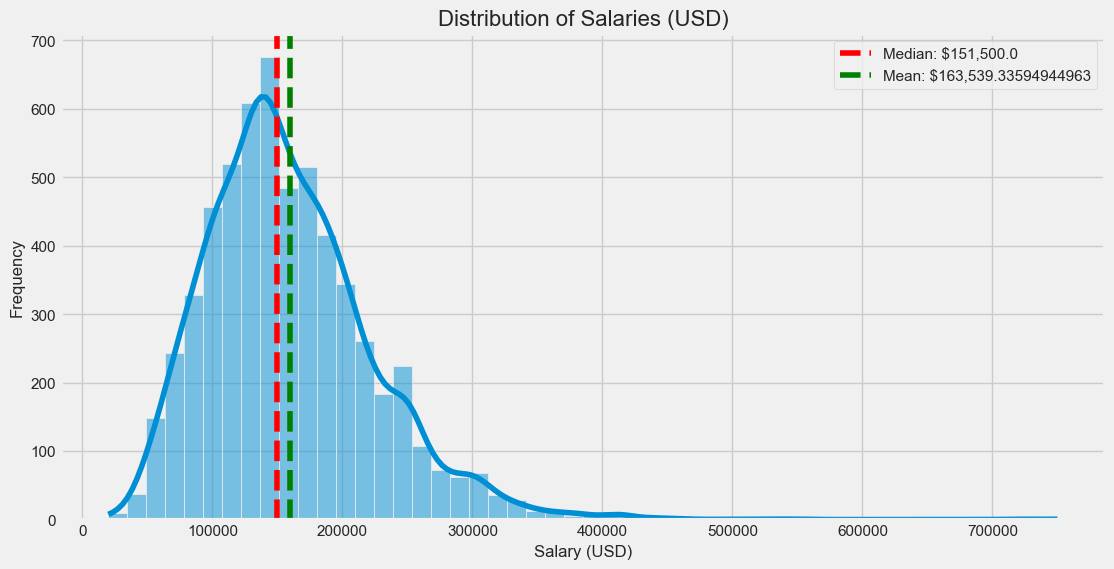

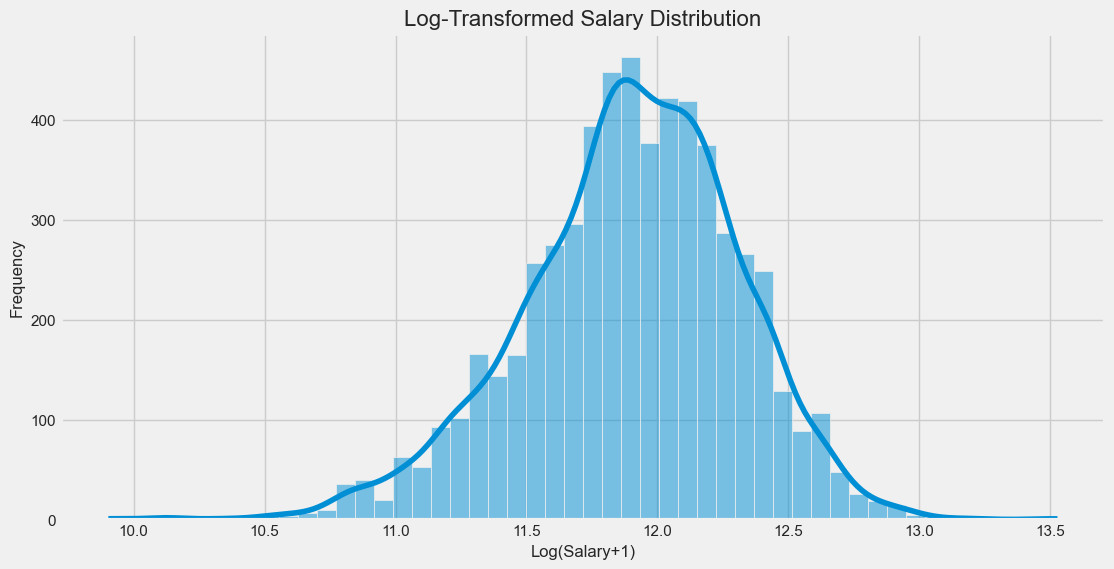

In [12]:
# Distribution of salaries in USD
plt.figure(figsize=(12, 6))
sns.histplot(train_df['salary_in_usd'], kde=True, bins=50)
plt.title('Distribution of Salaries (USD)', fontsize=16)
plt.xlabel('Salary (USD)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(train_df['salary_in_usd'].median(), color='red', linestyle='--', label=f'Median: ${df["salary_in_usd"].median():,}')
plt.axvline(train_df['salary_in_usd'].mean(), color='green', linestyle='--', label=f'Mean: ${df["salary_in_usd"].mean():,}')
plt.legend()
plt.show()

# Log-transformed salary distribution (to handle skewness)
plt.figure(figsize=(12, 6))
sns.histplot(np.log1p(train_df['salary_in_usd']), kde=True, bins=50)
plt.title('Log-Transformed Salary Distribution', fontsize=16)
plt.xlabel('Log(Salary+1)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

판단 근거: 왜 로그 변환이 필요할까?

1. 분포가 오른쪽으로 치우쳐 있음 (우측 비대칭, Right-skewed)
	•	히스토그램에서 **대부분의 값은 낮은 연봉 구간(예: $30k~$100k)**에 몰려 있고,
	•	**높은 연봉 구간(예: $200k 이상)**은 드물지만 아주 높은 값들이 존재합니다.
	•	이로 인해 분포의 꼬리가 오른쪽으로 길게 늘어나는 형태가 되며, 이는 전형적인 우측 비대칭입니다.

2. 평균(Mean)이 중앙값(Median)보다 오른쪽에 위치하고 있다면 → 극단적인 고액 연봉이 평균을 끌어올리는 상황이라는 뜻입니다.


고액 연봉 등의 극단값 영향 완화
선형 모델의 성능 저하
모델 학습 안정성 증가, 예측 정확도 향상
분산이 크고 값 범위가 큼
값의 스케일 축소, 스케일 균형 조정 가능

In [13]:
# 로그 변환
train_df['log_salary'] = np.log1p(train_df['salary_in_usd'])

# IQR 기반 이상치 경계 계산
Q1 = train_df['log_salary'].quantile(0.25)
Q3 = train_df['log_salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상치가 아닌 데이터만 남김
train_df = train_df[(train_df['log_salary'] >= lower_bound) & (train_df['log_salary'] <= upper_bound)].copy()

# 불필요한 log column 제거
train_df.drop(columns=['log_salary'], inplace=True)

# 결과 확인 (옵션)
print("이상치 제거 후 데이터 수:", len(train_df))

이상치 제거 후 데이터 수: 5799


In [15]:
# Yearly salary trends
yearly_stats = train_df.groupby('work_year')['salary_in_usd'].agg(['mean', 'median', 'std']).reset_index()

fig = px.line(yearly_stats, x='work_year', y=['mean', 'median'], 
              title='Data Science Salary Trends (2020-2025)',
              labels={'value': 'Salary (USD)', 'work_year': 'Year', 'variable': 'Metric'},
              template='plotly_white')

fig.update_layout(legend_title_text='', hovermode='x unified',
                 width=900, height=500)

# Add range for standard deviation
fig.add_trace(go.Scatter(
    x=np.concatenate([yearly_stats['work_year'], yearly_stats['work_year'][::-1]]),
    y=np.concatenate([yearly_stats['mean'] + yearly_stats['std'], 
                     (yearly_stats['mean'] - yearly_stats['std'])[::-1]]),
    fill='toself',
    fillcolor='rgba(0,100,80,0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    name='Standard Deviation'
))

fig.show()

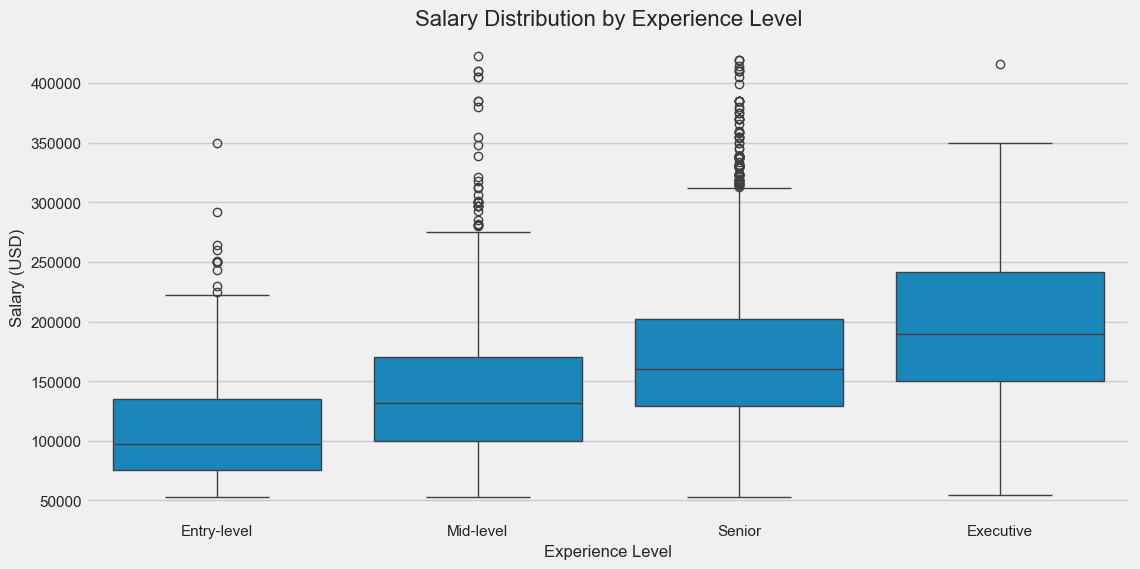

In [16]:
# Experience level salary comparison
plt.figure(figsize=(12, 6))
sns.boxplot(x='experience_level', y='salary_in_usd', data=train_df, order=['EN', 'MI', 'SE', 'EX'])
plt.title('Salary Distribution by Experience Level', fontsize=16)
plt.xlabel('Experience Level', fontsize=12)
plt.ylabel('Salary (USD)', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3], labels=['Entry-level', 'Mid-level', 'Senior', 'Executive'])
plt.show()



# Mean salary by experience level over time
exp_time = train_df.groupby(['work_year', 'experience_level'])['salary_in_usd'].mean().reset_index()
exp_time['experience_level'] = exp_time['experience_level'].replace({
    'EN': 'Entry-level', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'
})

# 연도 숫자를 문자열로 변환
exp_time['work_year'] = exp_time['work_year'].astype(str)

# 연도 순서 명시
year_order = ['2022', '2023', '2024']

# 경험 수준 레이블 변경
exp_time['experience_level'] = exp_time['experience_level'].replace({
    'EN': 'Entry-level', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'
})

fig = px.line(exp_time, x='work_year', y='salary_in_usd', color='experience_level',
             title='Salary Trends by Experience Level (2020-2024)',
             labels={'salary_in_usd': 'Average Salary (USD)', 'work_year': 'Year'},
             template='plotly_white')

fig.update_layout(width=900, height=500, hovermode='x unified')
fig.show()


Distribution of top job titles:
job_title
Data Scientist                    1229
Data Engineer                     1158
Data Analyst                       737
Machine Learning Engineer          541
Software Engineer                  294
Research Scientist                 181
Engineer                           162
Applied Scientist                  134
Data Architect                     128
Analytics Engineer                 120
Manager                             83
Research Engineer                   72
Business Intelligence Engineer      65
Data Manager                        50
Analyst                             47
Name: count, dtype: int64


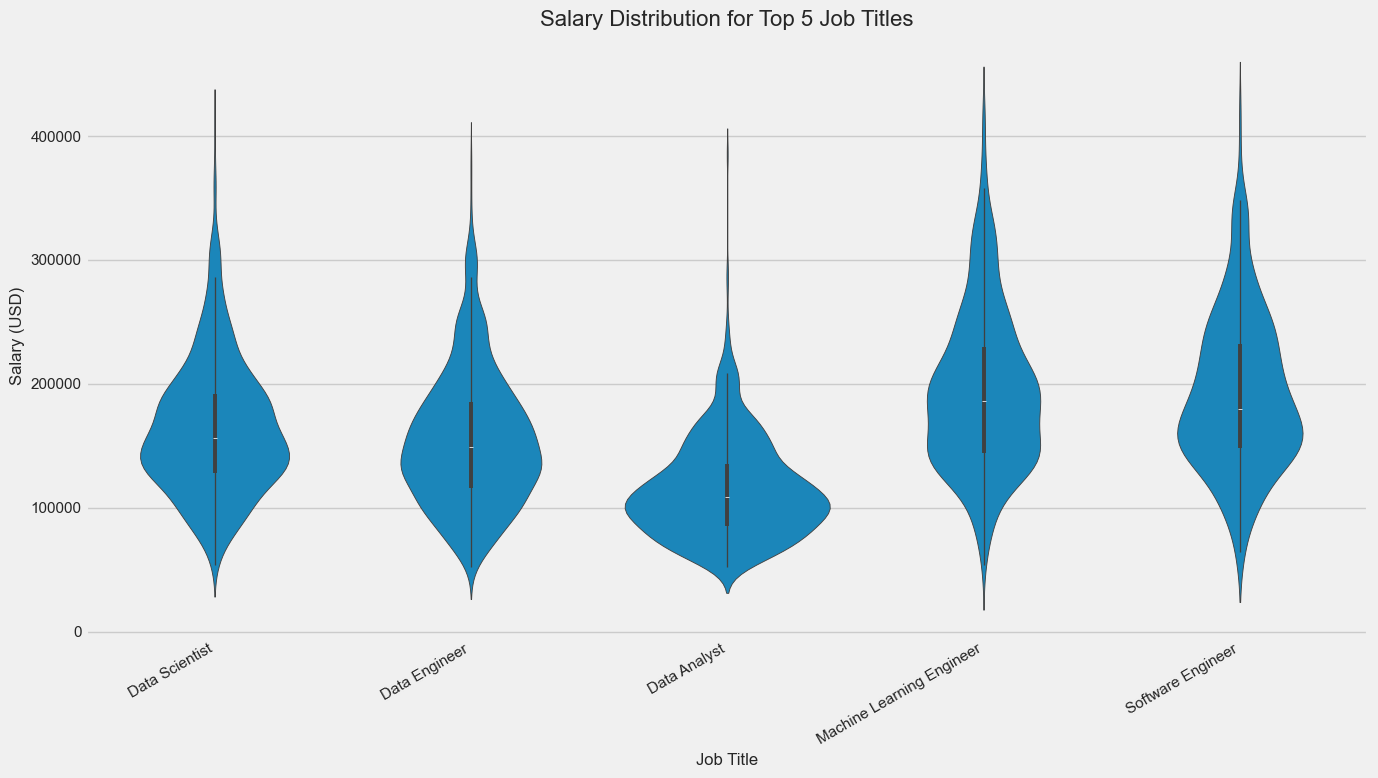

In [19]:
# Top 15 job titles by count
top_jobs = train_df['job_title'].value_counts().head(15)
print("Distribution of top job titles:")
print(top_jobs)

# Mean salary for top job titles
top_jobs_salary = train_df[train_df['job_title'].isin(top_jobs.index)].groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False)

fig = px.bar(x=top_jobs_salary.index, y=top_jobs_salary.values,
            labels={'x': 'Job Title', 'y': 'Average Salary (USD)'},
            title='Average Salary by Top Job Titles',
            color=top_jobs_salary.values, color_continuous_scale='Viridis')

fig.update_layout(xaxis_tickangle=-45, width=1000, height=600)
fig.show()

# Salary distribution for top 5 job titles
plt.figure(figsize=(14, 8))
top5_jobs = top_jobs.index[:5]
sns.violinplot(x='job_title', y='salary_in_usd', data=train_df[train_df['job_title'].isin(top5_jobs)])
plt.title('Salary Distribution for Top 5 Job Titles', fontsize=16)
plt.xlabel('Job Title', fontsize=12)
plt.ylabel('Salary (USD)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

가장 흔한 직무들 중에서는 머신러닝 엔지니어(Machine Learning Engineer) 와 리서치 사이언티스트(Research Scientist) 가 가장 높은 연봉을 받는 경향이 있는 반면, 데이터 분석가(Data Analyst) 는 상대적으로 낮은 연봉을 받는 것으로 나타났습니다.
또한 소프트웨어 엔지니어(Software Engineer) 는 연봉 분포의 폭이 가장 넓게 나타났는데, 이는 해당 직무에 포함된 역할의 다양성과 범위를 반영하는 결과로 해석할 수 있습니다.

In [23]:
# Salary by remote ratio
remote_salary = train_df.groupby('remote_ratio')['salary_in_usd'].agg(['mean', 'median', 'count']).reset_index()
remote_salary['remote_ratio'] = remote_salary['remote_ratio'].map({0: 'On-site', 50: 'Hybrid', 100: 'Remote'})

fig = px.bar(remote_salary, x='remote_ratio', y=['mean', 'median'],
            barmode='group', title='Salary by Remote Work Ratio',
            labels={'value': 'Salary (USD)', 'remote_ratio': 'Work Setting', 'variable': 'Metric'},
            color_discrete_sequence=['#2a9d8f', '#e76f51'])

fig.update_layout(width=800, height=500)
fig.show()

# Remote ratio trends over time
remote_time = train_df.groupby(['work_year', 'remote_ratio']).size().reset_index(name='count')
total_per_year = remote_time.groupby('work_year')['count'].sum().reset_index()
remote_time = remote_time.merge(total_per_year, on='work_year', suffixes=('', '_total'))
remote_time['percentage'] = (remote_time['count'] / remote_time['count_total']) * 100
remote_time['remote_ratio'] = remote_time['remote_ratio'].map({0: 'On-site', 50: 'Hybrid', 100: 'Remote'})

fig = px.line(remote_time, x='work_year', y='percentage', color='remote_ratio',
             title='Remote Work Trends (2020-2024)',
             labels={'percentage': 'Percentage of Jobs', 'work_year': 'Year'},
             template='plotly_white')

fig.update_layout(width=900, height=500, hovermode='x unified')
fig.show()

전면 원격 근무(Fully remote) 포지션은 평균적으로 더 높은 연봉을 제공하는 경향이 있습니다.
또한 2020년 이후, 특히 코로나19 팬데믹의 영향으로 인해 원격 근무 비중이 크게 증가한 것으로 나타났습니다.
이러한 추세는 2023~2024년경에 다소 안정세를 보였지만, 2020년 이전보다 여전히 높은 비율을 유지하고 있습니다.

In [24]:
# Salary by company size
company_salary = train_df.groupby(['company_size', 'experience_level'])['salary_in_usd'].median().reset_index()
company_salary['company_size'] = company_salary['company_size'].map({'S': 'Small', 'M': 'Medium', 'L': 'Large'})
company_salary['experience_level'] = company_salary['experience_level'].map({
    'EN': 'Entry-level', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'
})

fig = px.bar(company_salary, x='company_size', y='salary_in_usd', color='experience_level',
            barmode='group', title='Median Salary by Company Size and Experience Level',
            labels={'salary_in_usd': 'Median Salary (USD)', 'company_size': 'Company Size'},
            template='plotly_white')

fig.update_layout(width=900, height=500)
fig.show()

규모가 큰 기업일수록 모든 경력 수준에서 더 높은 연봉을 제공하는 경향이 있습니다.
특히 임원급(executive)에서 그 격차가 가장 두드러지며, 이는 대기업의 더 풍부한 자원과 수익 구조를 반영합니다.

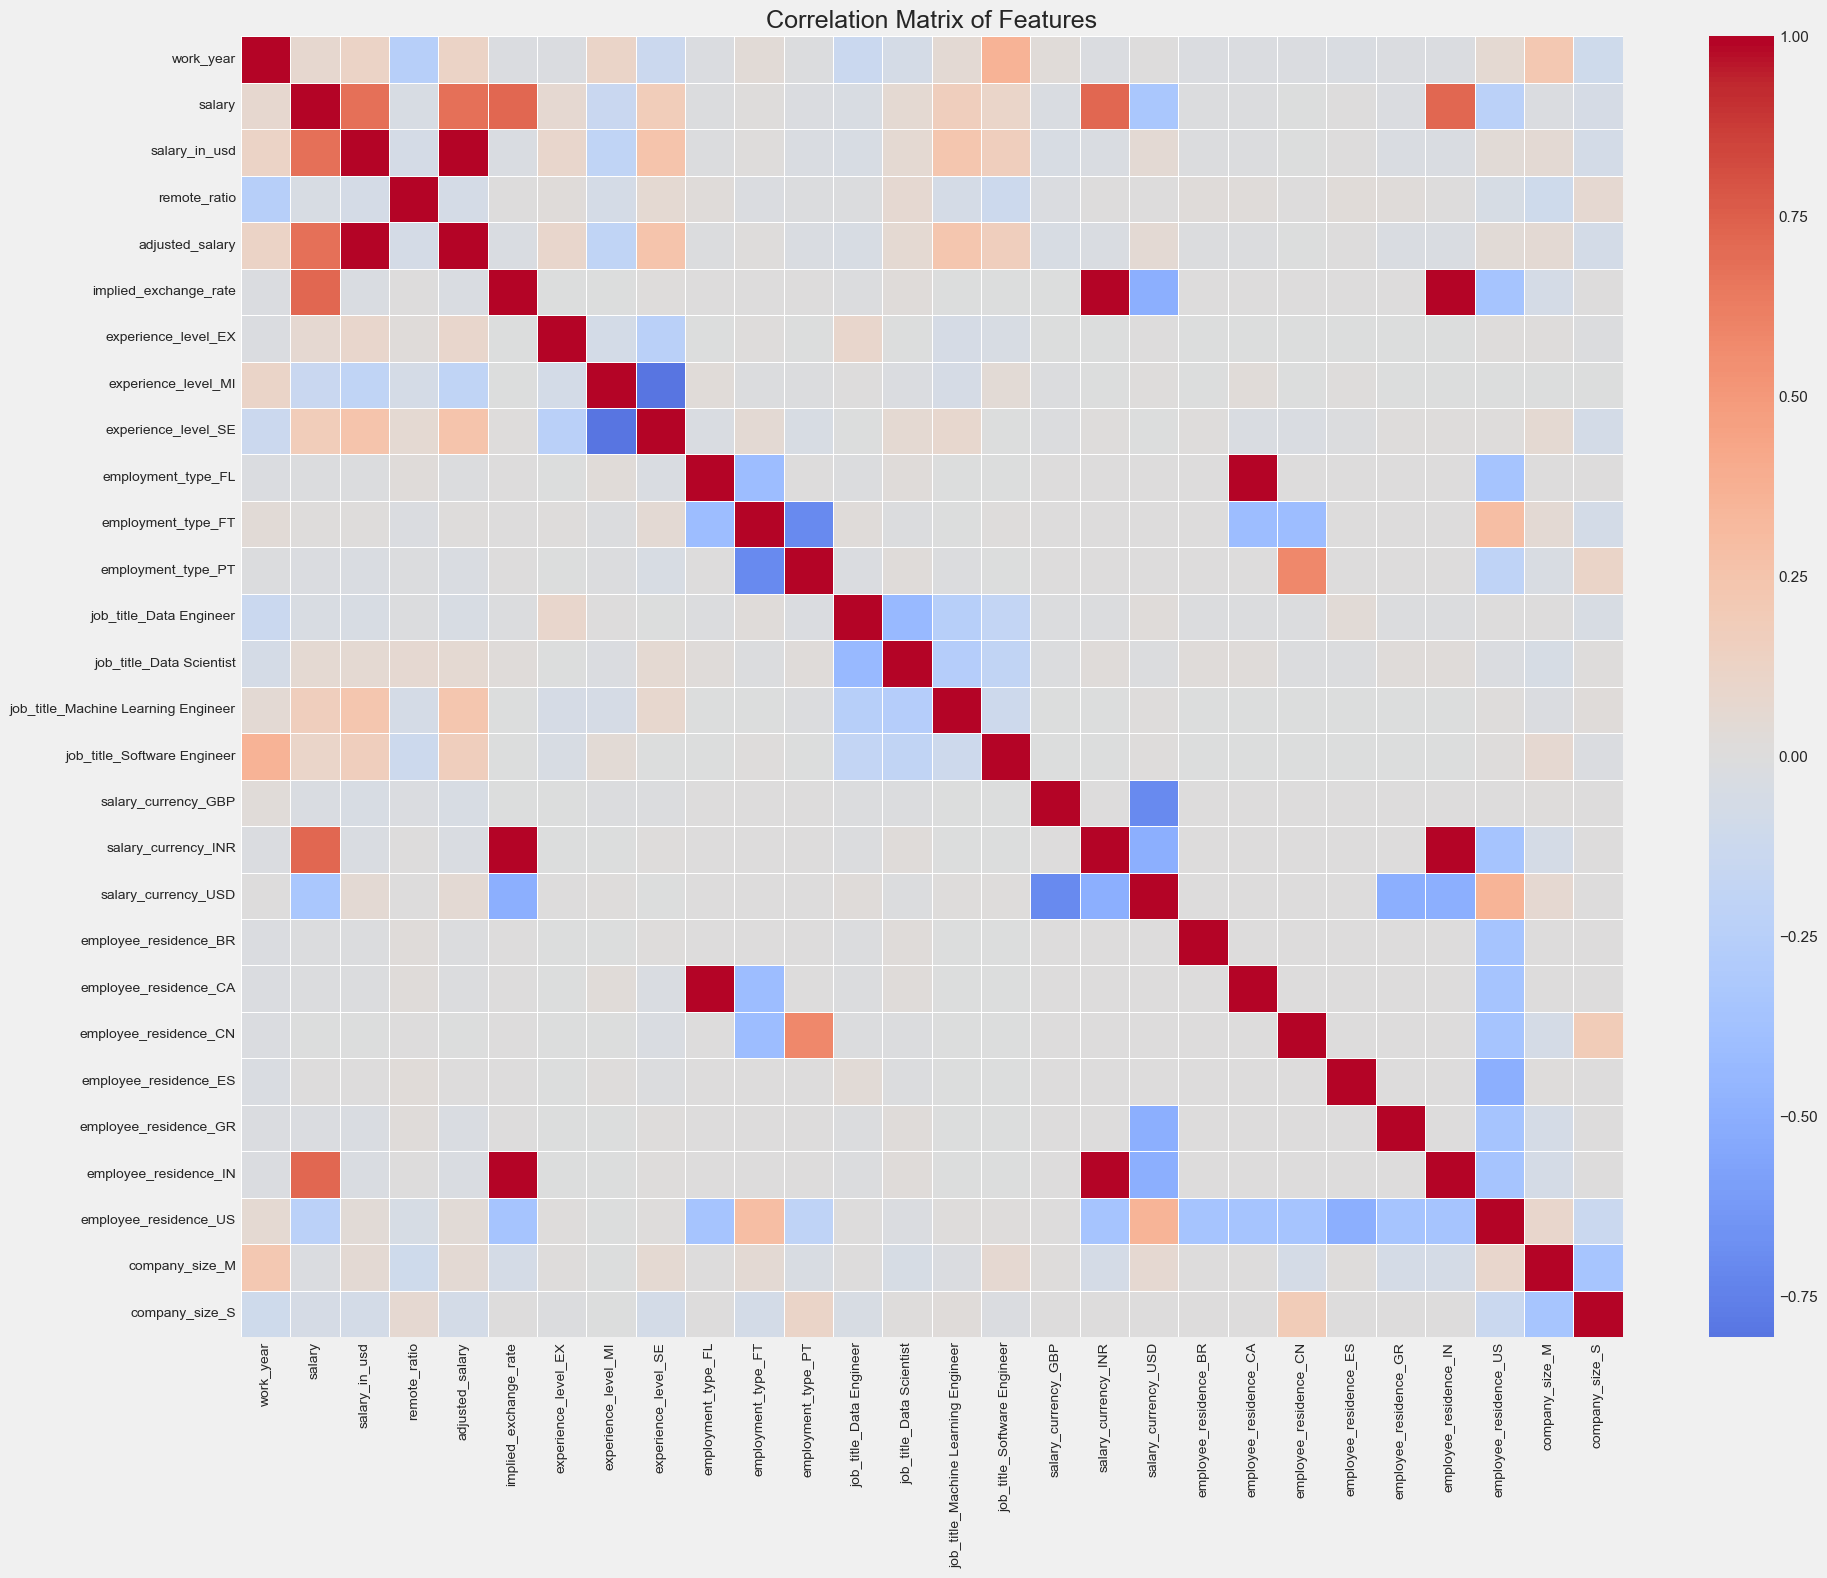

Top 10 features positively correlated with salary:
salary_in_usd                          1.000000
adjusted_salary                        1.000000
salary                                 0.675867
experience_level_SE                    0.253257
job_title_Machine Learning Engineer    0.242090
job_title_Software Engineer            0.162772
work_year                              0.123904
experience_level_EX                    0.092122
job_title_Data Scientist               0.061223
salary_currency_USD                    0.052368
company_size_M                         0.047587
Name: salary_in_usd, dtype: float64

Top 10 features negatively correlated with salary:
employee_residence_GR     -0.024081
employment_type_PT        -0.024449
implied_exchange_rate     -0.027743
employee_residence_IN     -0.027929
salary_currency_INR       -0.027929
salary_currency_GBP       -0.037260
job_title_Data Engineer   -0.039008
remote_ratio              -0.064976
company_size_S            -0.076035
experienc

In [27]:
# Create dummy variables for categorical features
categorical_cols = ['experience_level', 'employment_type', 'job_title', 'salary_currency', 
                    'employee_residence', 'company_location', 'company_size']
numerical_cols = ['work_year', 'salary', 'salary_in_usd', 'remote_ratio']

# Select top job titles for simplified correlation analysis
top_job_titles = train_df['job_title'].value_counts().head(5).index.tolist()
df_corr = train_df[train_df['job_title'].isin(top_job_titles)].copy()

# Create dummy variables
df_dummies = pd.get_dummies(df_corr, columns=categorical_cols, drop_first=True)

# Calculate and plot correlation matrix
corr_matrix = df_dummies.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix of Features', fontsize=18)
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Key salary correlations
salary_corr = corr_matrix['salary_in_usd'].sort_values(ascending=False)
print("Top 10 features positively correlated with salary:")
print(salary_corr.head(11))  # Including salary_in_usd itself
print("\nTop 10 features negatively correlated with salary:")
print(salary_corr.tail(10))

experience_level_SE 0.253 Senior 경력일수록 연봉이 높음   
job_title_Machine Learning Engineer 0.242 ML 엔지니어는 평균적으로 연봉이 높음  
job_title_Software Engineer 0.163 소프트웨어 엔지니어도 높은 연봉 추세  
work_year 0.124 연도 증가에 따라 연봉 증가 경향 (2020→2024)  

📌 결론 및 핵심 인사이트

데이터 과학 연봉 데이터셋에 대한 이번 종합 분석을 통해 다음과 같은 가치 있는 인사이트들을 도출할 수 있었습니다:

💼 연봉 결정 요인

경력 수준, 회사 위치, 직무 카테고리는 데이터 과학 분야에서 연봉을 예측하는 데 가장 강력한 변수로 작용합니다. 특히 임원급(Executive) 포지션은 다른 직급보다 월등히 높은 연봉을 받는 경향이 있습니다.

🌍 지리적 영향

미국, 스위스, 이스라엘은 지속적으로 가장 높은 연봉을 제공하는 국가들입니다. 이와 같은 상위 국가와 신흥 기술 시장 간에는 상당한 연봉 격차가 존재합니다.

🏠 원격 근무 프리미엄

완전 원격 근무는 평균적으로 더 높은 연봉을 제공하는 경향이 있습니다. 이는 위치에 상관없이 글로벌 인재 확보 경쟁이 치열해졌음을 반영합니다.

📈 경력 성장

시니어(Senior) → 임원(Executive) 단계로의 승진은 연봉 측면에서 가장 큰 증가폭을 보여줍니다. 이는 리더십 역량에 대한 프리미엄이 크게 작용하고 있음을 의미합니다.

👨‍🔬 직무별 연봉 차이

머신러닝 엔지니어와 **연구 과학자(Research Scientist)**는 데이터 분석가나 일반 소프트웨어 엔지니어보다 높은 연봉을 받는 경향이 있으며, 이는 고도의 전문 기술이 요구되는 직무 특성에 기인합니다.

🏢 기업 규모 효과

기업 규모가 클수록 전반적인 연봉이 높으며, 이 격차는 특히 임원급에서 더욱 뚜렷하게 나타납니다. 이는 자본력과 수익성이 높은 대기업의 구조를 반영합니다.

⸻

🛠️ 실용적 활용 방안

이번 분석 결과와 예측 모델은 다음과 같은 용도로 활용할 수 있습니다:
	•	경력 설계: 다양한 직무 전환 및 성장 경로의 경제적 영향을 정량적으로 이해
	•	연봉 협상: 실제 데이터 기반의 협상 근거 제공
	•	근무 위치 전략: 고연봉 국가 또는 원격 근무 기회 평가
	•	채용 전략: 데이터 과학 직군에 대해 경쟁력 있는 보상 체계 수립

⸻

🔮 향후 과제 및 확장 방향

분석의 깊이와 정밀도를 높이기 위해 다음과 같은 확장을 고려할 수 있습니다:
	•	교육 수준 및 보유 기술 데이터 통합
	•	**지역별 물가 반영(Cost of Living)**을 통한 연봉 실질 비교
	•	산업군(Industry Vertical) 구분을 통한 부문별 연봉 분석
	•	시계열 예측 모델을 활용한 향후 연봉 트렌드 예측

In [47]:
# 불필요한 컬럼 제거
cols_to_drop = ['salary', 'salary_currency', 'employee_residence', 'adjusted_salary', 'implied_exchange_rate', 'company_location']

train_df = train_df.drop(columns=cols_to_drop, errors='ignore')
test_df = test_df.drop(columns=cols_to_drop, errors='ignore')

print(train_df.columns)
print(test_df.columns)

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary_in_usd', 'remote_ratio', 'company_size'],
      dtype='object')
Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary_in_usd', 'remote_ratio', 'company_size'],
      dtype='object')


In [48]:
train_df.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,remote_ratio,company_size
0,2022,SE,FT,AI Architect,180000,100,M
1,2022,EN,FT,Machine Learning Scientist,80000,50,S
2,2022,SE,FT,Staff Machine Learning Engineer,185000,50,M
3,2022,SE,FT,Staff Data Scientist,164000,50,M
4,2022,EX,FT,Data Scientist,300000,100,L


In [49]:
# 0 : 신입 ~ 1년미만 1 : 2~5년차 2 :5년 이상 3 : 관리자급
train_df['experience_level'] = train_df['experience_level'].map({'EN' : 0, 'MI' : 1, 'SE' : 2, 'EX' : 3})
test_df['experience_level'] = test_df['experience_level'].map({'EN' : 0, 'MI' : 1, 'SE' : 2, 'EX' : 3})

# 0 : 풀타임 1 : 파트타임 2 : 계약직 3 : 프리랜서
train_df['employment_type'] = train_df['employment_type'].map({'FT' : 0, 'PT' : 1, 'CT' : 2, 'FL' : 3})
test_df['employment_type'] = test_df['employment_type'].map({'FT' : 0, 'PT' : 1, 'CT' : 2, 'FL' : 3})


# 0 : 50명 이내 1 : 500명 이내 2 : 501명 이상
train_df['company_size'] = train_df['company_size'].map({'S' : 0, 'M' : 1, 'L' : 2})
test_df['company_size'] = test_df['company_size'].map({'S' : 0, 'M' : 1, 'L' : 2})

train_df.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,remote_ratio,company_size
0,2022,2,0,AI Architect,180000,100,1
1,2022,0,0,Machine Learning Scientist,80000,50,0
2,2022,2,0,Staff Machine Learning Engineer,185000,50,1
3,2022,2,0,Staff Data Scientist,164000,50,1
4,2022,3,0,Data Scientist,300000,100,2


In [50]:
def map_job_group(title):
    if title in ['Machine Learning Engineer', 'Software Engineer', 'Data Scientist']:
        return 'High'
    elif title in ['AI Scientist', 'Applied Scientist', 'Research Scientist', 'ML Engineer']:
        return 'Mid'
    elif title in ['Data Analyst', 'BI Developer', 'Business Analyst', 'Data Engineer']:
        return 'Low'
    elif any(keyword in title for keyword in ['Manager', 'Lead', 'Head', 'Director', 'Principal']):
        return 'Leadership'
    else:
        return 'Other'

train_df['job_group'] = train_df['job_title'].apply(map_job_group)
test_df['job_group'] = test_df['job_title'].apply(map_job_group)

train_df.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,remote_ratio,company_size,job_group
0,2022,2,0,AI Architect,180000,100,1,Other
1,2022,0,0,Machine Learning Scientist,80000,50,0,Other
2,2022,2,0,Staff Machine Learning Engineer,185000,50,1,Other
3,2022,2,0,Staff Data Scientist,164000,50,1,Other
4,2022,3,0,Data Scientist,300000,100,2,High


In [51]:
del train_df['job_title']
del test_df['job_title']

train_df.head()

,work_year,experience_level,employment_type,salary_in_usd,remote_ratio,company_size,job_group
0,2022,2,0,180000,100,1,Other
1,2022,0,0,80000,50,0,Other
2,2022,2,0,185000,50,1,Other
3,2022,2,0,164000,50,1,Other
4,2022,3,0,300000,100,2,High


In [52]:
# 0 : High     1 : Mid      2 : Low      3 : Leadership      4 : Other
train_df['job_group'] = train_df['job_group'].map({'High' : 0, 'Mid' : 1, 'Low' : 2, 'Leadership' : 3, 'Other' : 4})
test_df['job_group'] = test_df['job_group'].map({'High' : 0, 'Mid' : 1, 'Low' : 2, 'Leadership' : 3, 'Other' : 4})

train_df.head()

,work_year,experience_level,employment_type,salary_in_usd,remote_ratio,company_size,job_group
0,2022,2,0,180000,100,1,4
1,2022,0,0,80000,50,0,4
2,2022,2,0,185000,50,1,4
3,2022,2,0,164000,50,1,4
4,2022,3,0,300000,100,2,0


In [ ]:
# Target과 Feature데이터로 분리 
train_target = train_df['salary_usd']
del train_df['salary_usd']

test_target = test_df['salary_usd']
del test_df['salary_usd']

In [58]:
# 범주형 컬럼 리스트
cat_cols = ['experience_level', 'employment_type', 'remote_ratio', 'company_size', 'job_group']

# One-Hot Encoding(범주형 데이터들의 변환)
# train, test 모두 인코딩 (drop_first=True는 다중공선성 제거용 선택 옵션)
train_encoded = pd.get_dummies(train_df, columns=cat_cols, drop_first=True)
test_encoded = pd.get_dummies(test_df, columns=cat_cols, drop_first=True)

# 열 불일치 방지: test에 없는 열을 추가
# 누락된 컬럼을 보완
missing_cols = set(train_encoded.columns) - set(test_encoded.columns)
for col in missing_cols:
    test_encoded[col] = 0

# 순서 일치
test_encoded = test_encoded[train_encoded.columns]

In [60]:
train_encoded

,work_year,salary_in_usd,experience_level_1,experience_level_2,experience_level_3,employment_type_1,employment_type_2,employment_type_3,remote_ratio_50,remote_ratio_100,company_size_1,company_size_2,job_group_1,job_group_2,job_group_3,job_group_4
0,2022,180000,False,True,False,False,False,False,False,True,True,False,False,False,False,True
1,2022,80000,False,False,False,False,False,False,True,False,False,False,False,False,False,True
2,2022,185000,False,True,False,False,False,False,True,False,True,False,False,False,False,True
3,2022,164000,False,True,False,False,False,False,True,False,True,False,False,False,False,True
4,2022,300000,False,False,True,False,False,False,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5886,2024,80000,False,False,False,False,False,False,False,True,True,False,False,True,False,False
5887,2024,133100,False,True,False,False,False,False,False,False,True,False,False,False,False,True
5888,2024,223600,True,False,False,False,False,False,False,False,False,True,False,False,False,False
5889,2024,147900,True,False,False,False,False,False,False,True,True,False,False,False,False,False


In [61]:
bool_cols = train_encoded.select_dtypes(include=['bool']).columns
train_encoded[bool_cols] = train_encoded[bool_cols].astype(int)

bool_cols_test = test_encoded.select_dtypes(include=['bool']).columns
test_encoded[bool_cols_test] = test_encoded[bool_cols_test].astype(int)

,work_year,salary_in_usd,experience_level_1,experience_level_2,experience_level_3,employment_type_1,employment_type_2,employment_type_3,remote_ratio_50,remote_ratio_100,company_size_1,company_size_2,job_group_1,job_group_2,job_group_3,job_group_4
0,2025,165000,0,1,0,0,0,0,0,0,1,0,0,0,0,1
1,2025,109000,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,2025,294000,0,1,0,0,0,0,0,0,1,0,1,0,0,0
3,2025,137600,0,1,0,0,0,0,0,0,1,0,1,0,0,0
4,2025,82000,0,0,0,0,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14110,2025,100000,0,0,0,0,0,0,0,1,1,0,0,0,0,1
14111,2025,156000,1,0,0,0,0,0,0,0,1,0,0,0,0,1
14112,2025,93600,1,0,0,0,0,0,0,0,1,0,0,0,0,1
14113,2025,190000,1,0,0,0,0,0,0,0,1,0,0,0,1,0


In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 🎯 로그 변환
y_train_log = np.log1p(train_encoded['salary_in_usd'])
X_train = train_encoded.drop(columns=['salary_in_usd'])
X_test = test_encoded.drop(columns=['salary_in_usd'], errors='ignore')  # test에 없을 수 있음

# ✅ 모델 학습
model = LinearRegression()
model.fit(X_train, y_train_log)

# 📈 예측 (로그 스케일 → 역변환)
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)  # 다시 원래 스케일로

# 평가 (원하면 train에서 검증셋 분리해서 확인 가능)
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr_log, y_val_log = train_test_split(X_train, y_train_log, test_size=0.2, random_state=42)
model.fit(X_tr, y_tr_log)
val_pred_log = model.predict(X_val)
val_pred = np.expm1(val_pred_log)
y_val = np.expm1(y_val_log)

print("✅ 검증 RMSE:", mean_squared_error(y_val, val_pred, squared=False))
print("✅ 검증 R²:", r2_score(y_val, val_pred))

✅ 검증 RMSE: 58202.61763217509
✅ 검증 R²: 0.128333740932275


ㅈ ㅋ 망 ㅋ